# MLP Classification of Fashion MNIST
Kelly Hung, CMPINF2222

In [113]:
#for visualizations
import matplotlib.pyplot as plt
#calculations
import math

#for deep learning functionalities
import torch
#neural network module to define model architectures
import torch.nn as nn
#for automatic batching, shuffling
from torch.utils.data import DataLoader, random_split

#torchvision for image datasets and transformations
import torchvision
from torchvision import datasets,transforms

#for reproducibility
import random
import numpy as np
torch.manual_seed(33)
random.seed(33)
np.random.seed(33)

## Methodology and Architecture

### Task Definition
For this project, 28x28 grayscale images are classified into 10 clothing categories with a multilayer perceptron (MLP). The input will be flattened, 784 pixel grayscale images and the output is the clothing categories. Since the training data is already labeled, the task will be supervised deep learning. 

Accuracy will be used as a primary evaluation for performance since the dataset is balanced (6,000 per category) and cross entropy loss to monitor during training and validation phase. Cross entropy loss is used since it is the standard loss function for classification tasks and measures difference between predicted proababilities vs actual labels.

For the final model evaluation, besides accuracy and loss, other measurements will be used. Precision, Recall, F1 score for more performance insight. Also confusion matrix to visually see misclassifications. 

### Data Preparation 

#### Data Preprocessing

ToTensor() Converts a PIL Image to Pytorch tensors and also changes range from [0,255] to [0,1]

Feature Engineering: when creating the models, nn.Flatten() is used to convert 2D image into 1D vector 

Documentation for FashionMNIST and ToTensor()

https://docs.pytorch.org/vision/stable/generated/torchvision.datasets.FashionMNIST.html

https://docs.pytorch.org/vision/main/generated/torchvision.transforms.ToTensor.html

In [114]:
train_set = datasets.FashionMNIST(
    root='./',
    download=True,
    train=True,
    transform=transforms.Compose([transforms.ToTensor()]) 
    #ToTensor() transforms PIL (Python Image Library) into tensors
)

test_set = datasets.FashionMNIST(
    root='./',
    download=True,
    train=False,
    transform=transforms.Compose([transforms.ToTensor()])
)

In [3]:
#checking that the training set and test set were loaded in
len(train_set)

60000

In [4]:
len(test_set)

10000

To determine appropriate metric for cost of error, the distribution of data must be checked. There are 6000 rows for each category which means the classes are balanced. Accuracy will be used as measurement.

In [5]:
labels = []
for _, label in train_set:
    labels.append(label)
    
labels = np.array(labels)

# Count each class
for i in range(10):
    print(f"Category {i}: {(labels == i).sum()} rows")

Category 0: 6000 rows
Category 1: 6000 rows
Category 2: 6000 rows
Category 3: 6000 rows
Category 4: 6000 rows
Category 5: 6000 rows
Category 6: 6000 rows
Category 7: 6000 rows
Category 8: 6000 rows
Category 9: 6000 rows


#### Train Test Validation Split

The ideal split ratio is approximately 70% training, 15% validation, and 15% test. Fashion MNIST test set already has a separate test set (10,000 images) and is approximately %14 (close to the ratio). So, 60,000 training images will be split into 49,500 training set and 10,5000 validation set.

The validation set is used for monitoring performance and for tuning hyperparameters (learning rate, layers, augmentation). This keeps test set completely isolated which prevents data leakage and an unbiased final evaluation. 

In [6]:
#Total(60,000+10,000) * 15 percent = number of rows for validation set 
70_000*0.15

10500.0

In [7]:
# training set = total - validation set
60_000-10_500

49500

In [8]:
#Defining training and validation set sizes
train_size = 49_500
val_size = 10_500

#random split accordingly to the sizes
train_set, val_set = random_split(
    train_set,
    [train_size, val_size]
)

In [9]:
#initializing dataloaders for each set 
train_loader = DataLoader(
    dataset=train_set,
    batch_size=32,
    shuffle=True
)

val_loader = DataLoader(
    dataset=val_set,
    batch_size=32,
    shuffle=True
)

test_loader = DataLoader(
    dataset=test_set,
    batch_size=32,
    shuffle=True
)

### Hyperparameter and Model Design

MLP is the focus of this assignment. Though theoretically CNN is better for detecting images, Fashion MNIST is simple enough to achieve accuracy without understanding of spatial relationsips. 

Certain layer sizes are chosen (784, 500, 300, 200, 100, 10) especially the first and last one. 784 for image's number of pixels. And 10 since there are 10 categories of clothing. The rest of the sizes are not as intentional, but there's a trend of decreasing in size to converge into 10. Three layers are chosen to be my baseline model as I think it's best to start off basic. In one experiment, I tried adding more hidden layers for a deeper network.

The model uses linear layers for weighted transformations and ReLU as an activation function. ReLU was picked for simplicity and matches the range the image was converted into (0 to 1). Other activation functions are used for experimentation just to see and understand if they can improve the model: Tanh and Sigmoid.

For regularization, I used Dropout. By using Dropout, it prevents the model from relying on specific neurons and forces it to learn more generalizable features which increases robustness. I chose 0.2 to randomly deactivate 20% of neurons during training. This was chosen as a balance between regularization effect and reducing model capacity.

10 epochs were chosen as a simple, standard starting point for the experiments. This allowed me to perform different experiments more quickly.

## Training and Optimization

I experimented with 9 different configurations:  baseline model, increased epochs, additional layers, regularization (dropout and data augmentation), activation functions (sigmoid, tanh),  and learning rates (faster and slower).

I have plotted cross entropy loss and accuracy for validation and training phases. Ideal curves is where the loss is minimal and decreases and accuracy is maximized and increases with more epochs.

Dropout, more hidden layers,  Sigmoid activation function, slower learning rate, and data augmentation seem to work well. They were favored since the curve trends are desirable and stable and more smooth than baseline model. Some had minimal gap between training and validation curves.

After identifying configurations that performed well, a final model was built with all the favored configurations combined, but the training time was slow due to data augmentation and the training and validation accuracy and loss curves did not converge. This suggests more epochs were needed but training time was too long. Data augmentation was dropped to see if the model still performed well and it did. However there was no convergence. I tried running the model again with more epochs. Despite accuracy and loss improvement, the values remained lower than individual configurations. Finally Sigmoid was removed to simplify the model and produced the best results: Val Loss 0.30 and Val Acc 89.32%.

For debugging, a major problem I ran into were inconsistencies in evaluations between runs. I learned to reset random seeds (torch, numpy, random) before any major run (my final models) to have reproducibility.

https://codesignal.com/learn/courses/building-a-neural-network-in-pytorch/lessons/training-a-neural-network-model-with-pytorch

In [10]:
# Function for training model
def train_model(epochs, model, optimizer, train_loader=train_loader, val_loader=val_loader):

    #Initializing Lists to keep track of average losses and accuracies
    #this will be used for plotting
    train_losses = []
    val_losses = []
    train_accuracies = []
    val_accuracies = []
    
    for n in range(epochs):
    #Training Portion
        model.train()
        #Keeping track of total loss, correctly trained, and total trained
        train_loss = 0.0
        train_correct = 0
        train_total = 0
        for images, y in train_loader:
            #forward pass
            outputs = model(images)#feeding in images through model
            loss = loss_function(outputs,y)#loss function defined below is Cross Entropy
    
            #backward pass
            optimizer.zero_grad() #optimizer is Adam and zero_grad makes gradients zero for the iteration
            loss.backward()#compute gradient of loss
            optimizer.step()#optimize moodel parameters
    
            # Accuracy calculation
            predicted = torch.argmax(outputs, dim=1) #find max in each class
            correct_predictions = (predicted == y) #finding matches and yields boolean
            train_correct += correct_predictions.sum().item() #sum all correctly predicted and add to list
            train_total += y.size(0) #adds batch size, counting total number of rows of data
            
            train_loss += loss.item()#item() converts loss to float number
            
        avg_train_loss = train_loss / len(train_loader)
        train_accuracy = train_correct / train_total * 100
        train_losses.append(avg_train_loss)
        train_accuracies.append(train_accuracy)
    
        #Validation Portion
        model.eval() 
        #.eval() turns off regularization in layers (batchnorm or dropout)
        #not needed in this specific model since it's simple MLP, but good practice to have
        val_correct = 0
        val_loss=0.0
        val_total=0
    
        with torch.no_grad():
            for images, y in val_loader:
                outputs = model(images)
                loss = loss_function(outputs,y)
                val_loss += loss.item()
                
                # Accuracy calculation
                predicted = torch.argmax(outputs, dim=1)
                correct_predictions = (predicted == y)
                val_correct += correct_predictions.sum().item()
                val_total += y.size(0)
                
        avg_val_loss = val_loss / len(val_loader)
        val_accuracy = val_correct / val_total * 100
        val_losses.append(avg_val_loss)
        val_accuracies.append(val_accuracy)
    
        print(f'Epoch {n+1}/{epochs} ,'
              f' Train Loss: {avg_train_loss:.2f} ,'
              f' Train Acc: {train_accuracy:.2f}% ,'
              f' Val Loss: {avg_val_loss:.2f} ,'
              f' Val Acc: {val_accuracy:.2f}%')
        
    return train_losses, val_losses, train_accuracies, val_accuracies  

In [11]:
#Function for plotting kearning curves: loss and accuracy
def plot_curves(train_losses, val_losses, train_accuracies, val_accuracies, title=''):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 6))
    
    # Loss
    ax1.plot(range(1, len(train_losses)+1), train_losses, label='Train Loss')
    ax1.plot(range(1, len(train_losses)+1), val_losses, label='Validation Loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.set_title('Model Loss')
    ax1.legend()
    
    # Accuracy
    ax2.plot(range(1, len(train_accuracies)+1), train_accuracies, label='Train Accuracy')
    ax2.plot(range(1, len(train_accuracies)+1), val_accuracies, label='Validation Accuracy')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy %')
    ax2.set_title('Model Accuracy')
    ax2.legend()
    
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

In [12]:
#Initializing loss function since task is for classification
loss_function = nn.CrossEntropyLoss()

#### Experiment 1: Baseline

In [13]:
model_1 = nn.Sequential(
    nn.Flatten(),
    nn.Linear(784,200), #784 because of image size
    nn.ReLU(),
    nn.Linear(200,100),
    nn.ReLU(),
    nn.Linear(100,10) #end with 10 since that's the number of categories
)

In [14]:
optimizer_1 = torch.optim.Adam(
    params=model_1.parameters(),
    lr=0.001
)

In [15]:
train_losses_1, val_losses_1, train_accuracies_1, val_accuracies_1 = train_model(
    epochs=10, model=model_1, optimizer=optimizer_1)

Epoch 1/10 , Train Loss: 0.53 , Train Acc: 80.95% , Val Loss: 0.40 , Val Acc: 85.78%
Epoch 2/10 , Train Loss: 0.38 , Train Acc: 86.04% , Val Loss: 0.37 , Val Acc: 86.29%
Epoch 3/10 , Train Loss: 0.34 , Train Acc: 87.56% , Val Loss: 0.34 , Val Acc: 88.08%
Epoch 4/10 , Train Loss: 0.32 , Train Acc: 88.20% , Val Loss: 0.33 , Val Acc: 88.21%
Epoch 5/10 , Train Loss: 0.30 , Train Acc: 88.97% , Val Loss: 0.35 , Val Acc: 87.01%
Epoch 6/10 , Train Loss: 0.28 , Train Acc: 89.29% , Val Loss: 0.32 , Val Acc: 88.49%
Epoch 7/10 , Train Loss: 0.27 , Train Acc: 89.88% , Val Loss: 0.30 , Val Acc: 89.29%
Epoch 8/10 , Train Loss: 0.26 , Train Acc: 90.25% , Val Loss: 0.29 , Val Acc: 89.42%
Epoch 9/10 , Train Loss: 0.25 , Train Acc: 90.63% , Val Loss: 0.29 , Val Acc: 89.78%
Epoch 10/10 , Train Loss: 0.24 , Train Acc: 91.05% , Val Loss: 0.30 , Val Acc: 89.26%


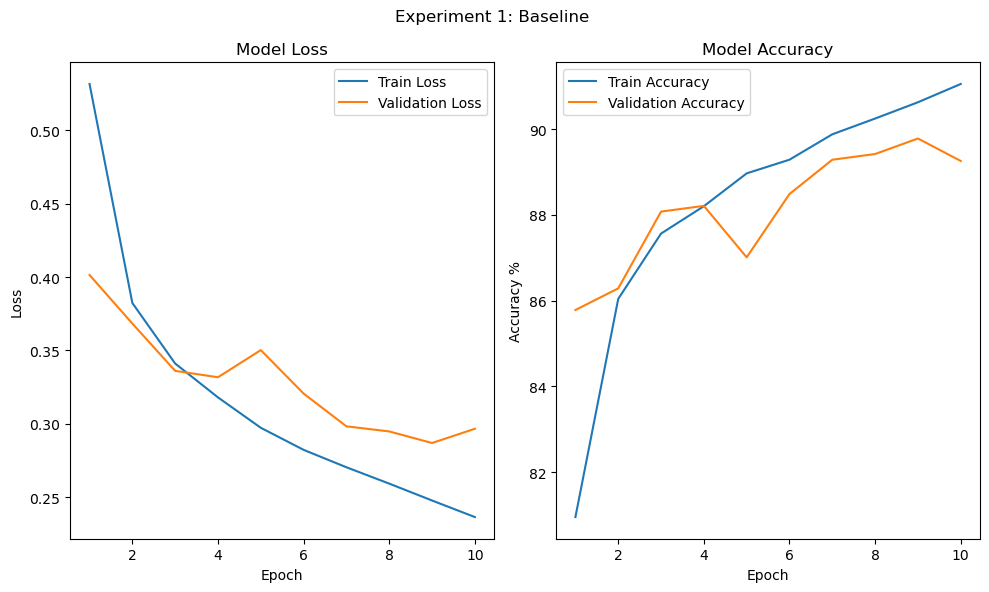

In [16]:
plot_curves(train_losses_1, val_losses_1, train_accuracies_1, val_accuracies_1,
            title='Experiment 1: Baseline ')

These results are decent. Overall validation loss decreasing and validation accuracy increasing are good trends

#### Experiment 2: More Epochs

In [17]:
#Using baseline's model and optimizer
train_losses_2, val_losses_2, train_accuracies_2, val_accuracies_2 = train_model(
    epochs=20, model=model_1, optimizer=optimizer_1)

Epoch 1/20 , Train Loss: 0.23 , Train Acc: 91.29% , Val Loss: 0.29 , Val Acc: 89.99%
Epoch 2/20 , Train Loss: 0.22 , Train Acc: 91.59% , Val Loss: 0.30 , Val Acc: 89.43%
Epoch 3/20 , Train Loss: 0.21 , Train Acc: 91.88% , Val Loss: 0.31 , Val Acc: 89.64%
Epoch 4/20 , Train Loss: 0.21 , Train Acc: 92.12% , Val Loss: 0.31 , Val Acc: 89.58%
Epoch 5/20 , Train Loss: 0.20 , Train Acc: 92.54% , Val Loss: 0.31 , Val Acc: 89.67%
Epoch 6/20 , Train Loss: 0.19 , Train Acc: 92.61% , Val Loss: 0.32 , Val Acc: 89.61%
Epoch 7/20 , Train Loss: 0.18 , Train Acc: 93.11% , Val Loss: 0.32 , Val Acc: 89.74%
Epoch 8/20 , Train Loss: 0.18 , Train Acc: 92.97% , Val Loss: 0.31 , Val Acc: 90.28%
Epoch 9/20 , Train Loss: 0.17 , Train Acc: 93.34% , Val Loss: 0.36 , Val Acc: 88.69%
Epoch 10/20 , Train Loss: 0.17 , Train Acc: 93.59% , Val Loss: 0.34 , Val Acc: 89.61%
Epoch 11/20 , Train Loss: 0.16 , Train Acc: 93.71% , Val Loss: 0.33 , Val Acc: 89.85%
Epoch 12/20 , Train Loss: 0.16 , Train Acc: 93.80% , Val Loss: 

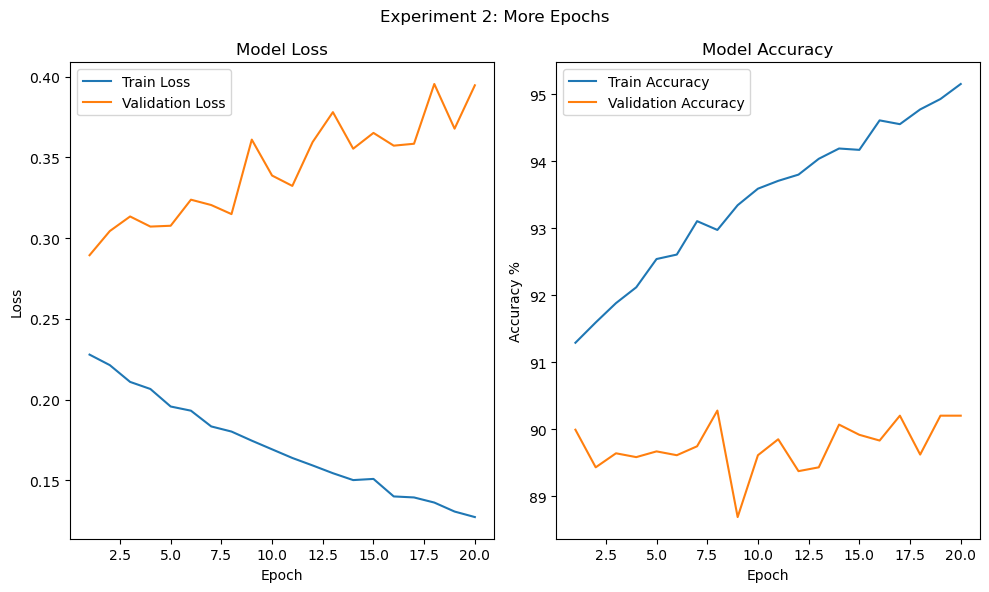

In [18]:
plot_curves(train_losses_2, val_losses_2, train_accuracies_2, val_accuracies_2,
            title='Experiment 2: More Epochs')

More epochs is causing overfitting. Validation loss increasing and validation accuracy is hovering around 89% to 90% isn't good. 

#### Experiment 3: More Hidden Layers

In [19]:
model_3 = nn.Sequential(
    nn.Flatten(),
    nn.Linear(784,500), #784 because of image size
    nn.ReLU(),
    nn.Linear(500,300),
    nn.ReLU(),
    nn.Linear(300,200),
    nn.ReLU(),
    nn.Linear(200,100),
    nn.ReLU(),
    nn.Linear(100,10) #end with 10 since that's the number of categories
)

In [20]:
optimizer_3 = torch.optim.Adam(
    params=model_3.parameters(),
    lr=0.001
)

In [21]:
train_losses_3, val_losses_3, train_accuracies_3, val_accuracies_3 = train_model(
    epochs=10, model=model_3, optimizer=optimizer_3)

Epoch 1/10 , Train Loss: 0.57 , Train Acc: 78.89% , Val Loss: 0.43 , Val Acc: 84.28%
Epoch 2/10 , Train Loss: 0.39 , Train Acc: 85.60% , Val Loss: 0.34 , Val Acc: 87.42%
Epoch 3/10 , Train Loss: 0.35 , Train Acc: 87.23% , Val Loss: 0.34 , Val Acc: 87.66%
Epoch 4/10 , Train Loss: 0.32 , Train Acc: 88.13% , Val Loss: 0.36 , Val Acc: 87.64%
Epoch 5/10 , Train Loss: 0.30 , Train Acc: 88.81% , Val Loss: 0.32 , Val Acc: 88.77%
Epoch 6/10 , Train Loss: 0.29 , Train Acc: 89.39% , Val Loss: 0.32 , Val Acc: 88.53%
Epoch 7/10 , Train Loss: 0.28 , Train Acc: 89.76% , Val Loss: 0.30 , Val Acc: 89.54%
Epoch 8/10 , Train Loss: 0.26 , Train Acc: 90.24% , Val Loss: 0.32 , Val Acc: 88.00%
Epoch 9/10 , Train Loss: 0.25 , Train Acc: 90.67% , Val Loss: 0.30 , Val Acc: 89.51%
Epoch 10/10 , Train Loss: 0.24 , Train Acc: 90.82% , Val Loss: 0.30 , Val Acc: 89.28%


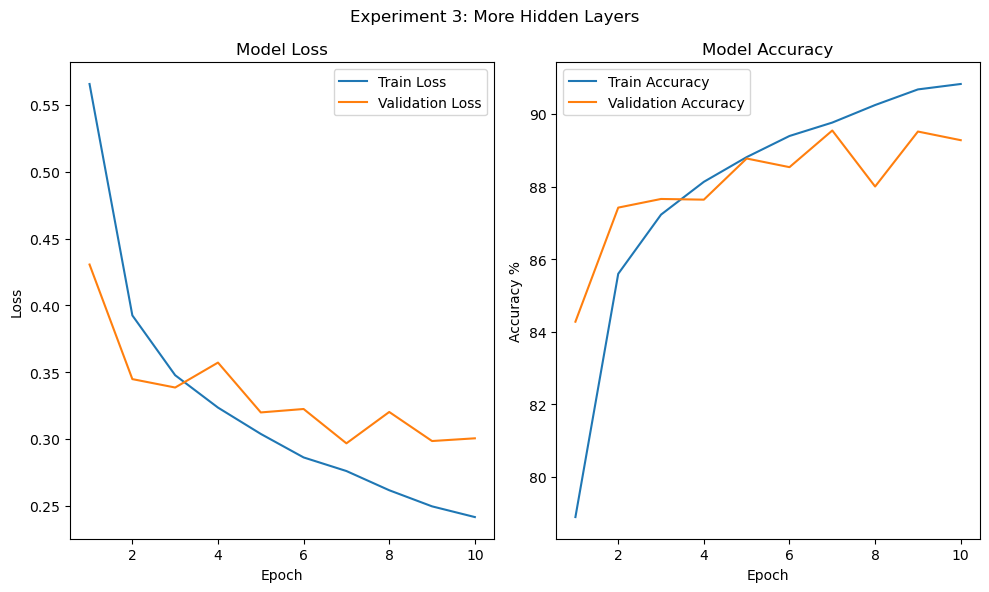

In [22]:
plot_curves(train_losses_3, val_losses_3, train_accuracies_3, val_accuracies_3,
            title='Experiment 3: More Hidden Layers')

Having a deeper network seemed to slightly stablize the curves compared to the baseline

#### Experiment 4: Adding Dropout

In [23]:
model_4 = nn.Sequential(
    nn.Flatten(),
    nn.Linear(784, 200),
    nn.ReLU(),
    nn.Dropout(0.2),
    nn.Linear(200, 100),
    nn.ReLU(),
    nn.Dropout(0.2),
    nn.Linear(100, 10)
)

In [24]:
optimizer_4 = torch.optim.Adam(
    params=model_4.parameters(),
    lr=0.001
)

In [25]:
train_losses_4, val_losses_4, train_accuracies_4, val_accuracies_4 = train_model(
    model=model_4, optimizer=optimizer_4, epochs=10)

Epoch 1/10 , Train Loss: 0.58 , Train Acc: 79.12% , Val Loss: 0.39 , Val Acc: 85.29%
Epoch 2/10 , Train Loss: 0.42 , Train Acc: 84.76% , Val Loss: 0.34 , Val Acc: 87.51%
Epoch 3/10 , Train Loss: 0.38 , Train Acc: 86.10% , Val Loss: 0.35 , Val Acc: 86.89%
Epoch 4/10 , Train Loss: 0.36 , Train Acc: 86.74% , Val Loss: 0.32 , Val Acc: 88.56%
Epoch 5/10 , Train Loss: 0.35 , Train Acc: 87.31% , Val Loss: 0.33 , Val Acc: 88.50%
Epoch 6/10 , Train Loss: 0.33 , Train Acc: 87.69% , Val Loss: 0.31 , Val Acc: 88.61%
Epoch 7/10 , Train Loss: 0.32 , Train Acc: 87.96% , Val Loss: 0.32 , Val Acc: 88.19%
Epoch 8/10 , Train Loss: 0.31 , Train Acc: 88.38% , Val Loss: 0.30 , Val Acc: 89.21%
Epoch 9/10 , Train Loss: 0.30 , Train Acc: 88.73% , Val Loss: 0.30 , Val Acc: 89.40%
Epoch 10/10 , Train Loss: 0.30 , Train Acc: 88.78% , Val Loss: 0.30 , Val Acc: 88.87%


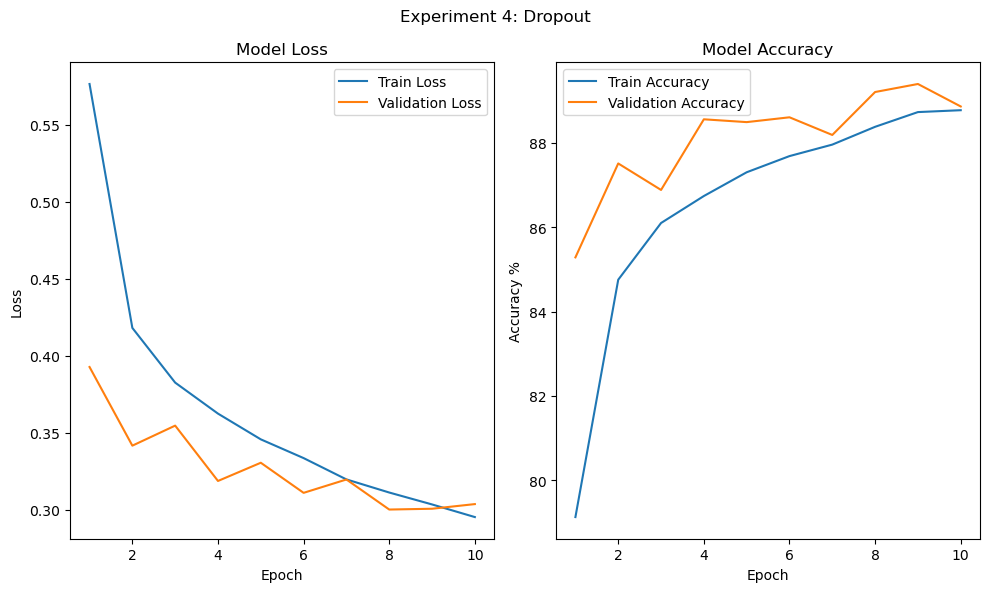

In [26]:
plot_curves(train_losses_4, val_losses_4, train_accuracies_4, val_accuracies_4,
            title='Experiment 4: Dropout')

Dropout is working as intended. It's more difficult for higher accuracy and lower loss in the training phase. The model works better in validation phase which is good sign.

#### Experiment 5: Different Activation Function - Sigmoid

In [27]:
model_5 = nn.Sequential(
    nn.Flatten(),
    nn.Linear(784, 200),
    nn.Sigmoid(),
    nn.Linear(200, 100),
    nn.Sigmoid(), 
    nn.Linear(100, 10)
)

In [28]:
optimizer_5 = torch.optim.Adam(
    params=model_5.parameters(),
    lr=0.001
)

In [29]:
train_losses_5, val_losses_5, train_accuracies_5, val_accuracies_5 = train_model(
    model=model_5, optimizer=optimizer_5, epochs=10)

Epoch 1/10 , Train Loss: 0.66 , Train Acc: 76.73% , Val Loss: 0.42 , Val Acc: 84.96%
Epoch 2/10 , Train Loss: 0.40 , Train Acc: 85.53% , Val Loss: 0.37 , Val Acc: 86.87%
Epoch 3/10 , Train Loss: 0.36 , Train Acc: 87.08% , Val Loss: 0.34 , Val Acc: 88.01%
Epoch 4/10 , Train Loss: 0.33 , Train Acc: 87.73% , Val Loss: 0.32 , Val Acc: 88.30%
Epoch 5/10 , Train Loss: 0.31 , Train Acc: 88.58% , Val Loss: 0.33 , Val Acc: 88.12%
Epoch 6/10 , Train Loss: 0.30 , Train Acc: 89.00% , Val Loss: 0.30 , Val Acc: 88.91%
Epoch 7/10 , Train Loss: 0.28 , Train Acc: 89.58% , Val Loss: 0.30 , Val Acc: 89.32%
Epoch 8/10 , Train Loss: 0.27 , Train Acc: 89.96% , Val Loss: 0.30 , Val Acc: 89.09%
Epoch 9/10 , Train Loss: 0.26 , Train Acc: 90.29% , Val Loss: 0.30 , Val Acc: 89.08%
Epoch 10/10 , Train Loss: 0.25 , Train Acc: 90.68% , Val Loss: 0.29 , Val Acc: 89.49%


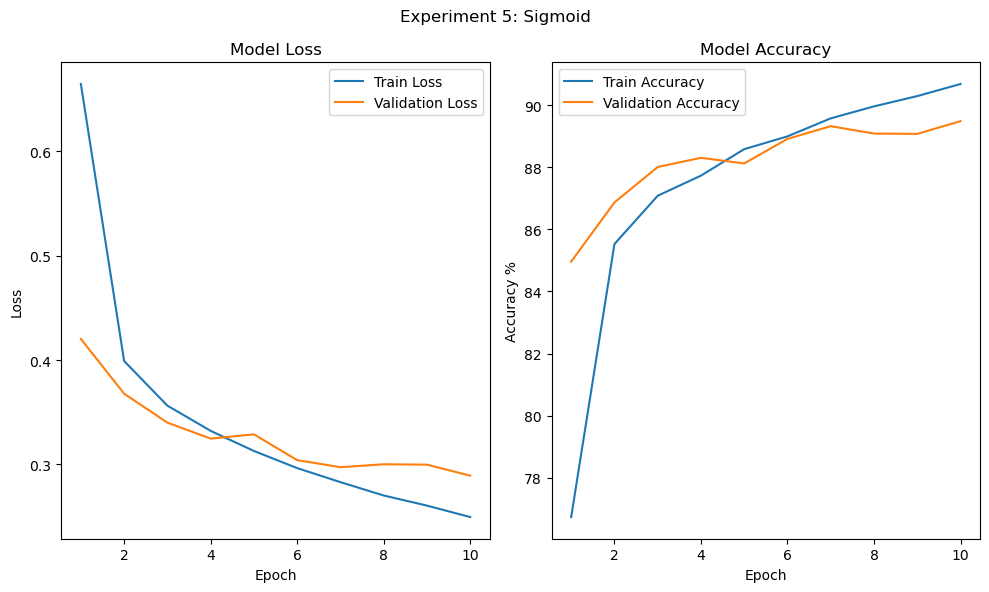

In [30]:
plot_curves(train_losses_5, val_losses_5, train_accuracies_5, val_accuracies_5,
            title='Experiment 5: Sigmoid')

Sigmoid works surprisingly well and has similar values to baseline, but the curves are much smoother.

#### Experiment 6: Different Activation Function - Tanh

In [31]:
model_6 = nn.Sequential(
    nn.Flatten(),
    nn.Linear(784, 200),
    nn.Tanh(),
    nn.Linear(200, 100),
    nn.Tanh(),
    nn.Linear(100, 10)
)

In [32]:
optimizer_6 = torch.optim.Adam(
    params=model_6.parameters(),
    lr=0.001
)

In [33]:
train_losses_6, val_losses_6, train_accuracies_6, val_accuracies_6 = train_model(
    model=model_6,
    optimizer=optimizer_6,
    epochs=10
)

Epoch 1/10 , Train Loss: 0.50 , Train Acc: 81.85% , Val Loss: 0.39 , Val Acc: 85.97%
Epoch 2/10 , Train Loss: 0.38 , Train Acc: 86.06% , Val Loss: 0.36 , Val Acc: 87.09%
Epoch 3/10 , Train Loss: 0.34 , Train Acc: 87.27% , Val Loss: 0.33 , Val Acc: 88.05%
Epoch 4/10 , Train Loss: 0.32 , Train Acc: 87.93% , Val Loss: 0.34 , Val Acc: 87.65%
Epoch 5/10 , Train Loss: 0.30 , Train Acc: 88.67% , Val Loss: 0.31 , Val Acc: 88.87%
Epoch 6/10 , Train Loss: 0.29 , Train Acc: 89.15% , Val Loss: 0.31 , Val Acc: 88.96%
Epoch 7/10 , Train Loss: 0.28 , Train Acc: 89.58% , Val Loss: 0.33 , Val Acc: 88.30%
Epoch 8/10 , Train Loss: 0.27 , Train Acc: 89.95% , Val Loss: 0.32 , Val Acc: 88.50%
Epoch 9/10 , Train Loss: 0.26 , Train Acc: 90.35% , Val Loss: 0.33 , Val Acc: 87.95%
Epoch 10/10 , Train Loss: 0.25 , Train Acc: 90.46% , Val Loss: 0.31 , Val Acc: 88.78%


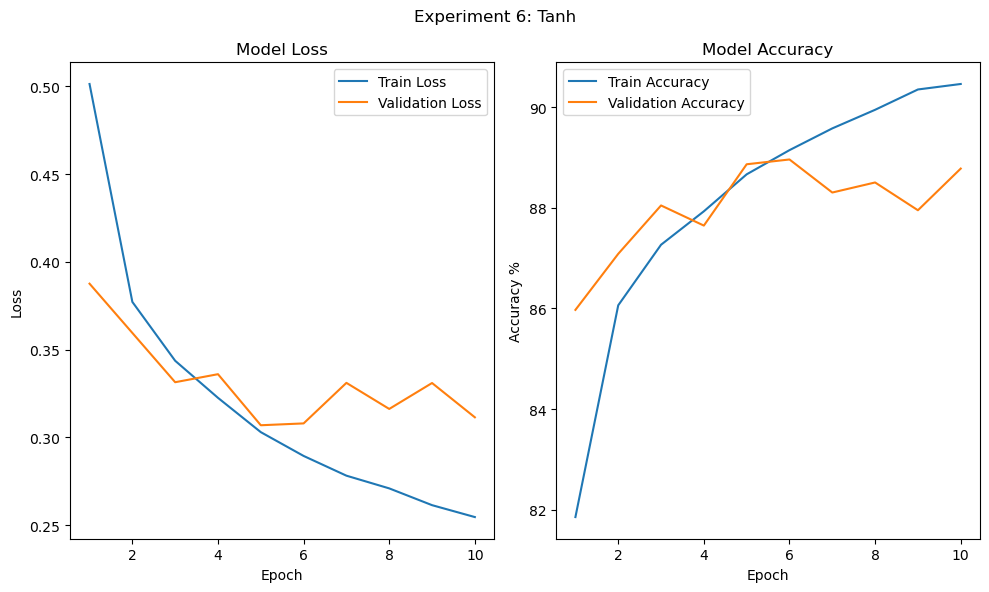

In [34]:
plot_curves(train_losses_6, val_losses_6, train_accuracies_6, val_accuracies_6,
            title='Experiment 6: Tanh')

Tanhh activation is not as good with no convergence pattern. Validation loss has a trend going up when there are more epochs meaning that there's overfitting and the model isn't generalizing as well.

#### Experiment 7: Different Learning Rate - Faster

In [35]:
model_7 = nn.Sequential(
    nn.Flatten(),
    nn.Linear(784, 200),
    nn.ReLU(),
    nn.Linear(200, 100),
    nn.ReLU(),
    nn.Linear(100, 10)
)

In [36]:
optimizer_7 = torch.optim.Adam(
    params=model_7.parameters(),
    lr=0.01
)

In [37]:
train_losses_7, val_losses_7, train_accuracies_7, val_accuracies_7 = train_model(
    model=model_7,
    optimizer=optimizer_7,
    epochs=10
)

Epoch 1/10 , Train Loss: 0.55 , Train Acc: 80.08% , Val Loss: 0.44 , Val Acc: 84.11%
Epoch 2/10 , Train Loss: 0.45 , Train Acc: 83.82% , Val Loss: 0.49 , Val Acc: 82.85%
Epoch 3/10 , Train Loss: 0.43 , Train Acc: 84.58% , Val Loss: 0.46 , Val Acc: 83.64%
Epoch 4/10 , Train Loss: 0.41 , Train Acc: 85.10% , Val Loss: 0.42 , Val Acc: 85.45%
Epoch 5/10 , Train Loss: 0.40 , Train Acc: 85.57% , Val Loss: 0.42 , Val Acc: 85.22%
Epoch 6/10 , Train Loss: 0.39 , Train Acc: 85.85% , Val Loss: 0.44 , Val Acc: 85.37%
Epoch 7/10 , Train Loss: 0.38 , Train Acc: 86.29% , Val Loss: 0.38 , Val Acc: 86.74%
Epoch 8/10 , Train Loss: 0.38 , Train Acc: 86.51% , Val Loss: 0.40 , Val Acc: 86.71%
Epoch 9/10 , Train Loss: 0.38 , Train Acc: 86.57% , Val Loss: 0.42 , Val Acc: 85.73%
Epoch 10/10 , Train Loss: 0.37 , Train Acc: 86.81% , Val Loss: 0.39 , Val Acc: 86.60%


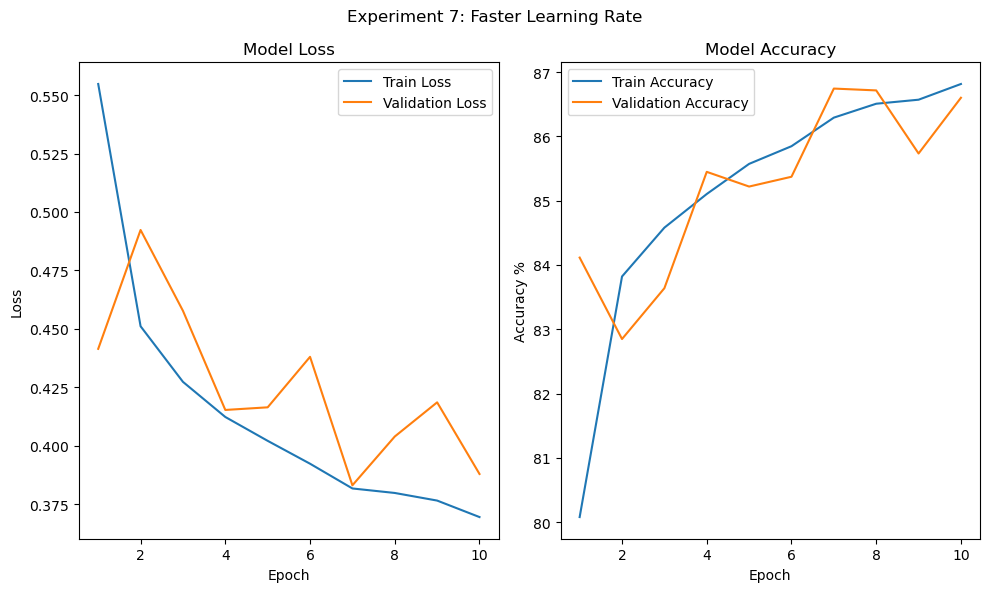

In [38]:
plot_curves(train_losses_7, val_losses_7, train_accuracies_7, val_accuracies_7,
            title='Experiment 7: Faster Learning Rate')

Faster learning is not good. The learning rate is too fast that the validation loss and accuracy are bouncing around wildly (overshooting). 

#### Experiment 8: Different Learning Rate - Slower

In [39]:
model_8 = nn.Sequential(
    nn.Flatten(),
    nn.Linear(784, 200),
    nn.ReLU(),
    nn.Linear(200, 100),
    nn.ReLU(),
    nn.Linear(100, 10)
)

In [40]:
optimizer_8 = torch.optim.Adam(
    params=model_8.parameters(),
    lr=0.0001
)

In [41]:
train_losses_8, val_losses_8, train_accuracies_8, val_accuracies_8 = train_model(
    model=model_8,
    optimizer=optimizer_8,
    epochs=10
)

Epoch 1/10 , Train Loss: 0.80 , Train Acc: 73.02% , Val Loss: 0.52 , Val Acc: 81.94%
Epoch 2/10 , Train Loss: 0.50 , Train Acc: 82.91% , Val Loss: 0.45 , Val Acc: 84.52%
Epoch 3/10 , Train Loss: 0.45 , Train Acc: 84.44% , Val Loss: 0.43 , Val Acc: 84.22%
Epoch 4/10 , Train Loss: 0.42 , Train Acc: 85.25% , Val Loss: 0.41 , Val Acc: 85.58%
Epoch 5/10 , Train Loss: 0.40 , Train Acc: 85.96% , Val Loss: 0.38 , Val Acc: 86.80%
Epoch 6/10 , Train Loss: 0.39 , Train Acc: 86.38% , Val Loss: 0.38 , Val Acc: 87.04%
Epoch 7/10 , Train Loss: 0.37 , Train Acc: 86.83% , Val Loss: 0.36 , Val Acc: 87.32%
Epoch 8/10 , Train Loss: 0.36 , Train Acc: 87.19% , Val Loss: 0.36 , Val Acc: 87.40%
Epoch 9/10 , Train Loss: 0.35 , Train Acc: 87.36% , Val Loss: 0.35 , Val Acc: 87.83%
Epoch 10/10 , Train Loss: 0.34 , Train Acc: 87.80% , Val Loss: 0.34 , Val Acc: 87.85%


Lower rate seems promising since validation accuracy is still in an upward trend and just need more epochs

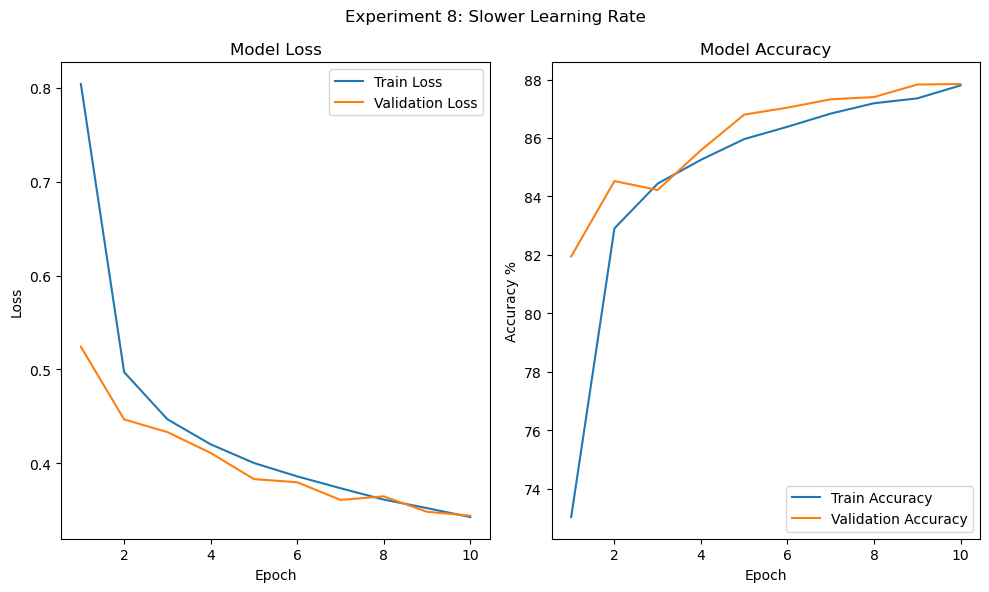

In [42]:
plot_curves(train_losses_8, val_losses_8, train_accuracies_8, val_accuracies_8,
            title='Experiment 8: Slower Learning Rate')

The curves are more smooth and training and validation curves converges

#### Experiment 9: Data Augmentation

Link to different data augmentations available: https://docs.pytorch.org/vision/stable/transforms.html

In [43]:
# Loading in training set with data augmentation
train_set_aug = datasets.FashionMNIST(
    root='./',
    download=True,
    train=True,
    transform=transforms.Compose([
    transforms.RandomHorizontalFlip(), #random horizontal flip 50% of time
    transforms.GaussianBlur(kernel_size=3), #blur 
    transforms.RandomPosterize(bits=3), #reduce color info to 3 bits
    transforms.RandomInvert(p=0.05), #inverts pixel values 5% of time
    transforms.RandomAutocontrast(), #random contrast
    transforms.ToTensor()
    ])
)

In [44]:
# Split train set to 49,500 and validation set 10,500 
train_data_9, val_data_9 = random_split(
    train_set_aug,
    [train_size, val_size]
)

In [45]:
# New DataLoaders
train_loader_9 = DataLoader(
    dataset=train_data_9,
    batch_size=32,
    shuffle=True
)

val_loader_9 = DataLoader(
    dataset=val_data_9,
    batch_size=32,
    shuffle=False
)

In [46]:
model_9 = nn.Sequential(
    nn.Flatten(),
    nn.Linear(784, 200),
    nn.ReLU(),
    nn.Linear(200, 100),
    nn.ReLU(),
    nn.Linear(100, 10)
)

In [47]:
optimizer_9 = torch.optim.Adam(
    params=model_9.parameters(),
    lr=0.001
)

In [48]:
train_losses_9, val_losses_9, train_accuracies_9, val_accuracies_9 = train_model(
    model=model_9, optimizer=optimizer_9, epochs=10,
    train_loader=train_loader_9,
    val_loader=val_loader_9
)

Epoch 1/10 , Train Loss: 0.65 , Train Acc: 76.08% , Val Loss: 0.48 , Val Acc: 81.99%
Epoch 2/10 , Train Loss: 0.46 , Train Acc: 83.02% , Val Loss: 0.46 , Val Acc: 82.30%
Epoch 3/10 , Train Loss: 0.42 , Train Acc: 84.45% , Val Loss: 0.39 , Val Acc: 85.41%
Epoch 4/10 , Train Loss: 0.40 , Train Acc: 85.38% , Val Loss: 0.40 , Val Acc: 85.32%
Epoch 5/10 , Train Loss: 0.38 , Train Acc: 86.01% , Val Loss: 0.37 , Val Acc: 86.12%
Epoch 6/10 , Train Loss: 0.37 , Train Acc: 86.45% , Val Loss: 0.37 , Val Acc: 86.44%
Epoch 7/10 , Train Loss: 0.36 , Train Acc: 86.70% , Val Loss: 0.37 , Val Acc: 86.17%
Epoch 8/10 , Train Loss: 0.35 , Train Acc: 87.00% , Val Loss: 0.35 , Val Acc: 86.90%
Epoch 9/10 , Train Loss: 0.34 , Train Acc: 87.56% , Val Loss: 0.35 , Val Acc: 87.26%
Epoch 10/10 , Train Loss: 0.33 , Train Acc: 87.78% , Val Loss: 0.34 , Val Acc: 87.50%


Training for this is significantly longer since there are multiple data augmentations for images. More epochs might be needed to attain higher accuracy.

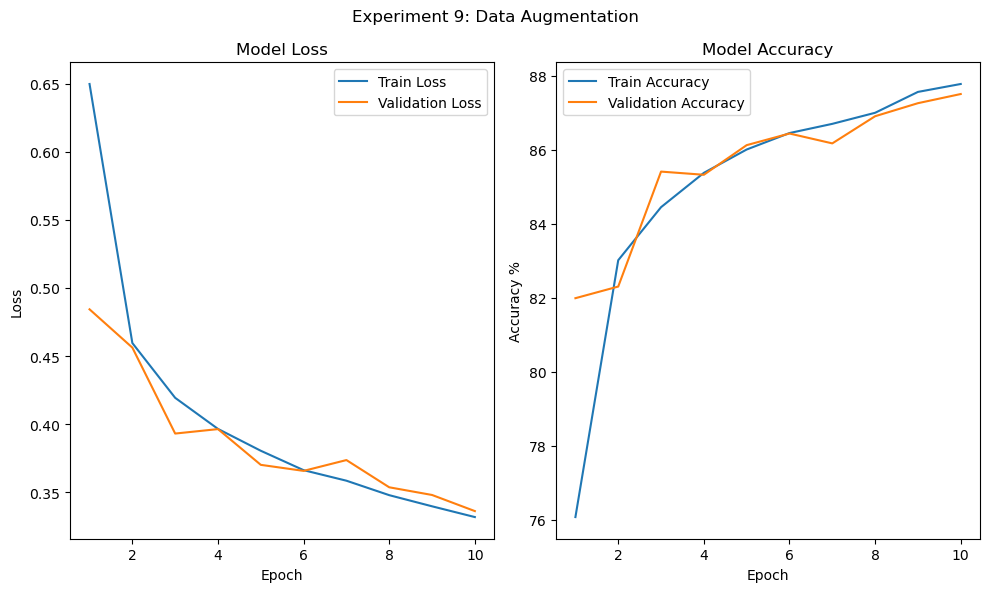

In [49]:
plot_curves(train_losses_9, val_losses_9, train_accuracies_9, val_accuracies_9,
            title='Experiment 9: Data Augmentation')

Training and validation curves are really close to each other. The generalization seems to work well here

### Final Model

For the final model I tried different combinations of hyperparameters that I thought can improve the model based on the experiments. The first model included everything: more hidden layers, Dropout, Slower learning rate, Sigmoid, Data Augmentation

NOTE: Due to time constraints, plot titles were not updated for each final model name. All plots are correctly generated and correspond to the header titles.

#### Final Model 1: More hidden layers, Dropout, Slower learning rate, Sigmoid, Data Augmentation

In [63]:
#Rerunning the random seeds before final model
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

In [66]:
final_model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(784, 500),
    nn.Sigmoid(),
    nn.Dropout(0.2),
    nn.Linear(500, 300),
    nn.Sigmoid(),
    nn.Dropout(0.2),
    nn.Linear(300, 200),
    nn.Sigmoid(),
    nn.Dropout(0.2),
    nn.Linear(200, 100),
    nn.Sigmoid(),
    nn.Dropout(0.2),
    nn.Linear(100, 10)
)

In [67]:
optimizer_final = torch.optim.Adam(
    params=final_model.parameters(),
    lr=0.0001
)

In [68]:
train_losses_final, val_losses_final, train_accuracies_final, val_accuracies_final = train_model(
    model=final_model, optimizer=optimizer_final, epochs=10,
    train_loader=train_loader_9,
    val_loader=val_loader_9
)

Epoch 1/10 , Train Loss: 1.92 , Train Acc: 23.64% , Val Loss: 1.56 , Val Acc: 42.80%
Epoch 2/10 , Train Loss: 1.41 , Train Acc: 42.69% , Val Loss: 1.24 , Val Acc: 54.29%
Epoch 3/10 , Train Loss: 1.17 , Train Acc: 54.45% , Val Loss: 1.03 , Val Acc: 60.40%
Epoch 4/10 , Train Loss: 1.01 , Train Acc: 60.38% , Val Loss: 0.89 , Val Acc: 63.49%
Epoch 5/10 , Train Loss: 0.92 , Train Acc: 62.22% , Val Loss: 0.83 , Val Acc: 65.59%
Epoch 6/10 , Train Loss: 0.87 , Train Acc: 64.02% , Val Loss: 0.78 , Val Acc: 68.01%
Epoch 7/10 , Train Loss: 0.81 , Train Acc: 66.70% , Val Loss: 0.73 , Val Acc: 70.44%
Epoch 8/10 , Train Loss: 0.77 , Train Acc: 69.04% , Val Loss: 0.68 , Val Acc: 72.30%
Epoch 9/10 , Train Loss: 0.73 , Train Acc: 71.07% , Val Loss: 0.66 , Val Acc: 73.50%
Epoch 10/10 , Train Loss: 0.70 , Train Acc: 72.56% , Val Loss: 0.62 , Val Acc: 75.30%


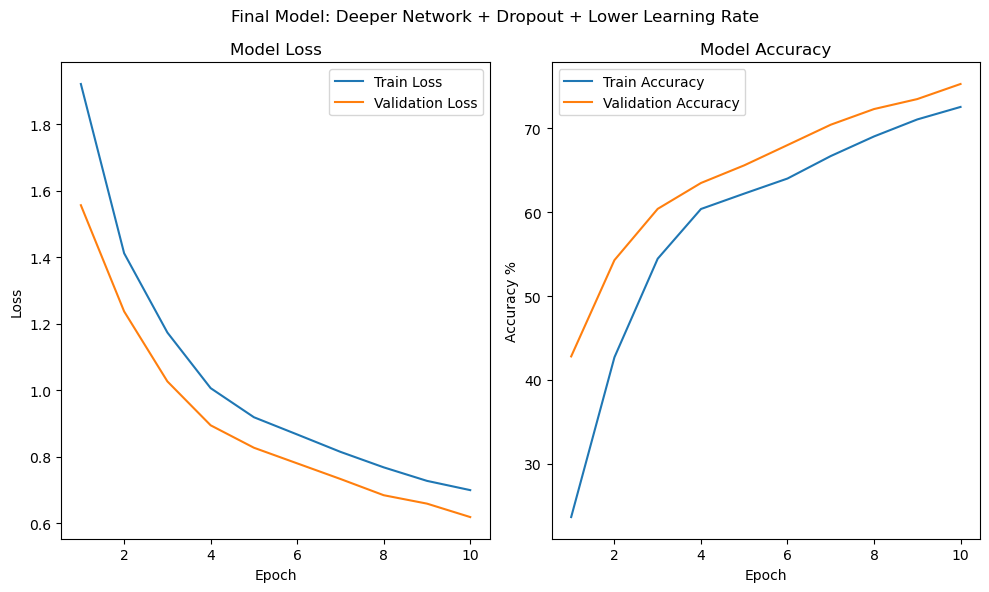

In [69]:
plot_curves(train_losses_final, val_losses_final, train_accuracies_final, val_accuracies_final,
            title='Final Model: More hidden layers, Dropout, Slower learning rate, Sigmoid, Data Augmentation')

The validation loss and accuracy is really good, but need much more epochs. Maybe the model can run okay without data augmentation

#### Final Model 2: More hidden layers, Dropout, Slower learning rate, Sigmoid

In [92]:
#Rerunning the random seeds again
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

#reinitializing the model and optimizer
final_model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(784, 500),
    nn.Sigmoid(),
    nn.Dropout(0.2),
    nn.Linear(500, 300),
    nn.Sigmoid(),
    nn.Dropout(0.2),
    nn.Linear(300, 200),
    nn.Sigmoid(),
    nn.Dropout(0.2),
    nn.Linear(200, 100),
    nn.Sigmoid(),
    nn.Dropout(0.2),
    nn.Linear(100, 10)
)

optimizer_final = torch.optim.Adam(
    params=final_model.parameters(),
    lr=0.0001
)

In [93]:
train_losses_final, val_losses_final, train_accuracies_final, val_accuracies_final = train_model(
    model=final_model, optimizer=optimizer_final, epochs=10,
)

Epoch 1/10 , Train Loss: 1.83 , Train Acc: 27.30% , Val Loss: 1.35 , Val Acc: 50.74%
Epoch 2/10 , Train Loss: 1.16 , Train Acc: 52.51% , Val Loss: 0.98 , Val Acc: 59.93%
Epoch 3/10 , Train Loss: 0.94 , Train Acc: 62.26% , Val Loss: 0.81 , Val Acc: 67.53%
Epoch 4/10 , Train Loss: 0.81 , Train Acc: 68.71% , Val Loss: 0.70 , Val Acc: 73.43%
Epoch 5/10 , Train Loss: 0.72 , Train Acc: 72.47% , Val Loss: 0.62 , Val Acc: 75.50%
Epoch 6/10 , Train Loss: 0.66 , Train Acc: 75.30% , Val Loss: 0.57 , Val Acc: 78.65%
Epoch 7/10 , Train Loss: 0.61 , Train Acc: 77.28% , Val Loss: 0.53 , Val Acc: 80.43%
Epoch 8/10 , Train Loss: 0.57 , Train Acc: 79.42% , Val Loss: 0.50 , Val Acc: 82.12%
Epoch 9/10 , Train Loss: 0.54 , Train Acc: 80.96% , Val Loss: 0.47 , Val Acc: 83.17%
Epoch 10/10 , Train Loss: 0.52 , Train Acc: 82.06% , Val Loss: 0.46 , Val Acc: 84.03%


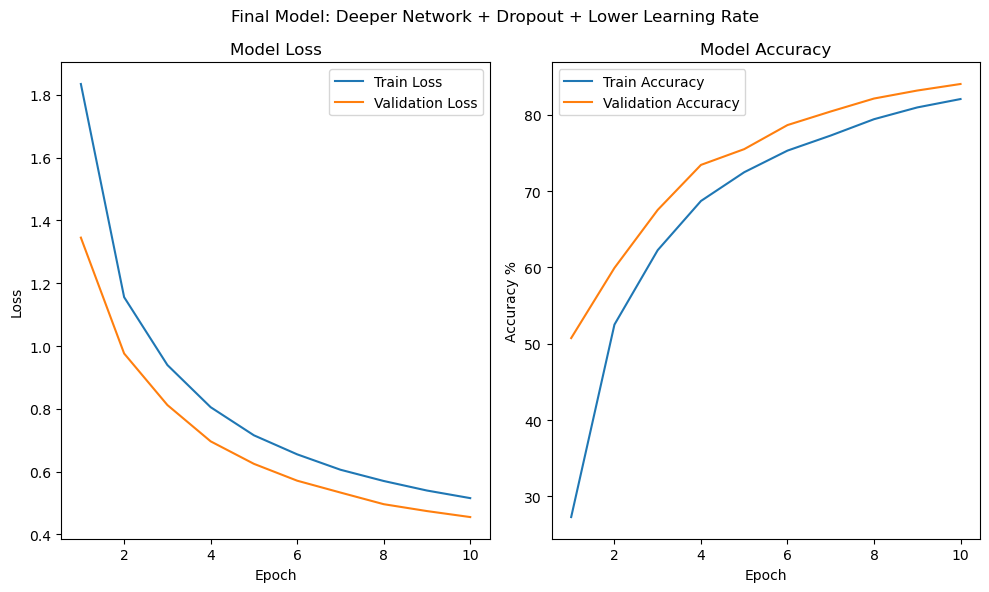

In [94]:
plot_curves(train_losses_final, val_losses_final, train_accuracies_final, val_accuracies_final,
            title='Final Model: More hidden layers, Dropout, Slower learning rate, Sigmoid')

The curve shapes are good, but it made me think if there would be improvement to accuracy and loss when running more epochs

#### Final Model 3: More hidden layers, Dropout, Slower learning rate, Sigmoid, more Epochs

In [96]:
#Rerunning the random seeds again
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

#reinitializing the model and optimizer
final_model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(784, 500),
    nn.Sigmoid(),
    nn.Dropout(0.2),
    nn.Linear(500, 300),
    nn.Sigmoid(),
    nn.Dropout(0.2),
    nn.Linear(300, 200),
    nn.Sigmoid(),
    nn.Dropout(0.2),
    nn.Linear(200, 100),
    nn.Sigmoid(),
    nn.Dropout(0.2),
    nn.Linear(100, 10)
)

optimizer_final = torch.optim.Adam(
    params=final_model.parameters(),
    lr=0.0001
)

In [97]:
train_losses_final, val_losses_final, train_accuracies_final, val_accuracies_final = train_model(
    model=final_model, optimizer=optimizer_final, epochs=20,
)

Epoch 1/20 , Train Loss: 1.83 , Train Acc: 27.30% , Val Loss: 1.35 , Val Acc: 50.74%
Epoch 2/20 , Train Loss: 1.16 , Train Acc: 52.51% , Val Loss: 0.98 , Val Acc: 59.93%
Epoch 3/20 , Train Loss: 0.94 , Train Acc: 62.26% , Val Loss: 0.81 , Val Acc: 67.53%
Epoch 4/20 , Train Loss: 0.81 , Train Acc: 68.71% , Val Loss: 0.70 , Val Acc: 73.43%
Epoch 5/20 , Train Loss: 0.72 , Train Acc: 72.47% , Val Loss: 0.62 , Val Acc: 75.50%
Epoch 6/20 , Train Loss: 0.66 , Train Acc: 75.30% , Val Loss: 0.57 , Val Acc: 78.65%
Epoch 7/20 , Train Loss: 0.61 , Train Acc: 77.28% , Val Loss: 0.53 , Val Acc: 80.43%
Epoch 8/20 , Train Loss: 0.57 , Train Acc: 79.42% , Val Loss: 0.50 , Val Acc: 82.12%
Epoch 9/20 , Train Loss: 0.54 , Train Acc: 80.96% , Val Loss: 0.47 , Val Acc: 83.17%
Epoch 10/20 , Train Loss: 0.52 , Train Acc: 82.06% , Val Loss: 0.46 , Val Acc: 84.03%
Epoch 11/20 , Train Loss: 0.50 , Train Acc: 82.41% , Val Loss: 0.44 , Val Acc: 84.40%
Epoch 12/20 , Train Loss: 0.49 , Train Acc: 83.13% , Val Loss: 

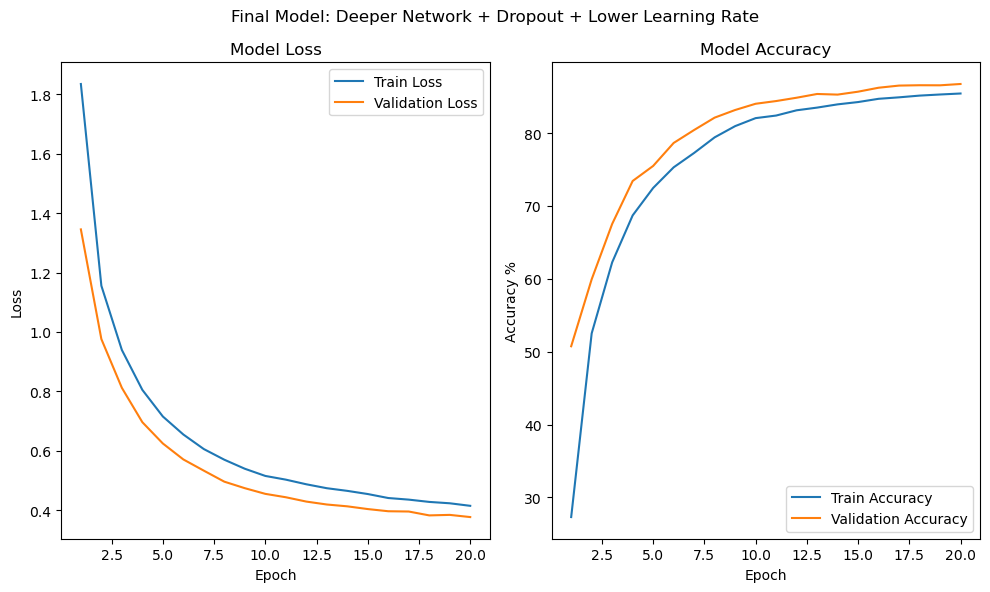

In [98]:
plot_curves(train_losses_final, val_losses_final, train_accuracies_final, val_accuracies_final,
            title='Final Model: More hidden layers, Dropout, Slower learning rate, Sigmoid, more Epochs')

Accuracy and loss is improved, but not as good when conducting the experiments with each hyperparmeter individually. I think dropping more things like sigmoid might work

#### Final Model 4: More hidden layers, Dropout, Slower learning rate

In [108]:
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

final_model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(784, 500),
    nn.ReLU(),
    nn.Dropout(0.2),
    nn.Linear(500, 300),
    nn.ReLU(),
    nn.Dropout(0.2),
    nn.Linear(300, 200),
    nn.ReLU(),
    nn.Dropout(0.2),
    nn.Linear(200, 100),
    nn.ReLU(),
    nn.Dropout(0.2),
    nn.Linear(100, 10)
)

optimizer_final = torch.optim.Adam(
    params=final_model.parameters(),
    lr=0.0001
)

In [109]:
train_losses_final, val_losses_final, train_accuracies_final, val_accuracies_final = train_model(
    model=final_model, optimizer=optimizer_final, epochs=10,
)

Epoch 1/10 , Train Loss: 0.88 , Train Acc: 67.40% , Val Loss: 0.52 , Val Acc: 81.43%
Epoch 2/10 , Train Loss: 0.53 , Train Acc: 81.55% , Val Loss: 0.42 , Val Acc: 84.97%
Epoch 3/10 , Train Loss: 0.45 , Train Acc: 84.10% , Val Loss: 0.38 , Val Acc: 86.50%
Epoch 4/10 , Train Loss: 0.41 , Train Acc: 85.49% , Val Loss: 0.35 , Val Acc: 87.17%
Epoch 5/10 , Train Loss: 0.38 , Train Acc: 86.40% , Val Loss: 0.34 , Val Acc: 87.63%
Epoch 6/10 , Train Loss: 0.36 , Train Acc: 87.17% , Val Loss: 0.33 , Val Acc: 88.24%
Epoch 7/10 , Train Loss: 0.34 , Train Acc: 87.71% , Val Loss: 0.32 , Val Acc: 88.67%
Epoch 8/10 , Train Loss: 0.33 , Train Acc: 88.14% , Val Loss: 0.32 , Val Acc: 88.43%
Epoch 9/10 , Train Loss: 0.32 , Train Acc: 88.56% , Val Loss: 0.31 , Val Acc: 88.90%
Epoch 10/10 , Train Loss: 0.31 , Train Acc: 88.89% , Val Loss: 0.30 , Val Acc: 89.32%


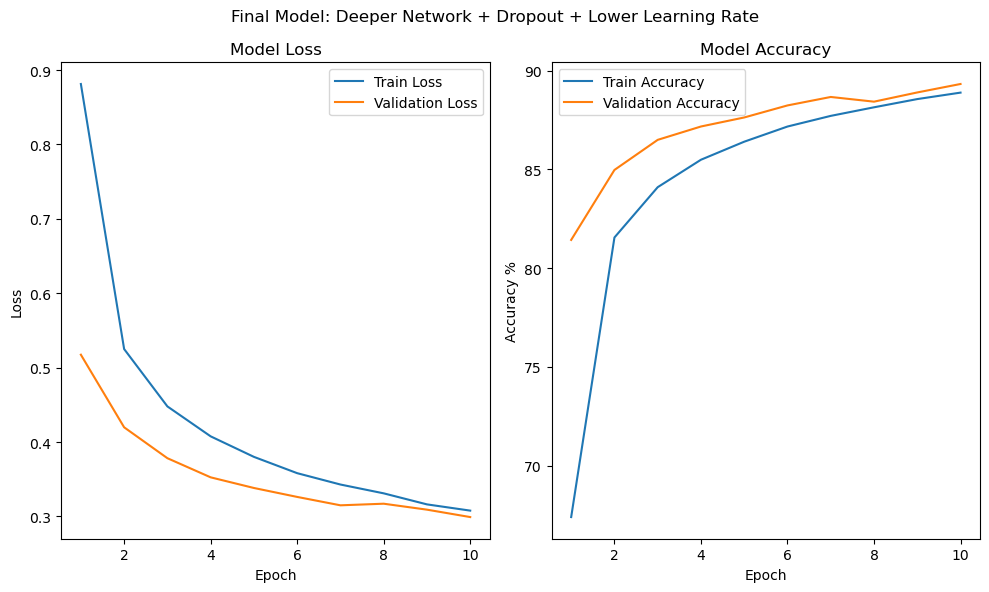

In [110]:
plot_curves(train_losses_final, val_losses_final, train_accuracies_final, val_accuracies_final,
            title='Final Model: More hidden layers, Dropout, Slower learning rate')

There is convergence between train and validation. Compared to the other final models, this is more simple, runs faster, has the highest accuracy and lowest loss. This model will be my final one and used for submission

In [127]:
torch.save(final_model.state_dict(), 'model_proj1.pth')

## Reflection and Analysis

Running the final model with the test data set yielded loss of 0.34 and accuracy of 87.98%. This is a decent result however it shows that things are being misclassified for a reason. By looking at the confusion matrix, there are some significant patterns. T-shirt being misllabeled as shirt (113 count). Coats (151 count) and shirt (63 count) being misllabeled as pullover. Pullover being misllabeled as coat (151 count). It seems the model has a hard time differentiating between these categories and mixes them up due to similar shapes and pixel patterns.

Looking into the classification report, the pattern is confirmed. Trouser had the best precision (0.99),  recall (0.97), f1-score (0.98) probably because its visually unique. Other clothing items are not similar at all. I imagine if there were skirts or shorts, the values wouldn't be as high. The same applies to bag, ankle boot, sandal, sneaker as they have a more distinctive appearance and achieved high scores.

### Evaluation

In [115]:
# Test set evaluation
final_model.eval()
test_loss = 0.0
test_correct = 0
test_total = 0

with torch.no_grad():
    for images, y in test_loader:
        outputs = final_model(images)
        loss = loss_function(outputs, y)
        
        test_loss += loss.item()
        
        predicted = torch.argmax(outputs, dim=1)
        correct_predictions = (predicted == y)
        test_correct += correct_predictions.sum().item()
        test_total += y.size(0)

avg_test_loss = test_loss / len(test_loader)
test_accuracy = test_correct / test_total * 100

print(f'Loss: {avg_test_loss:.2f}')
print(f'Accuracy: {test_accuracy:.2f}%')

Loss: 0.3401
Accuracy: 87.98%


In [112]:
all_predictions = []
all_labels = []

final_model.eval()
with torch.no_grad():
    for images, y in test_loader:
        outputs = final_model(images)
        predicted = torch.argmax(outputs, dim=1)
        
        all_predictions.extend(predicted.numpy())
        all_labels.extend(y.numpy())

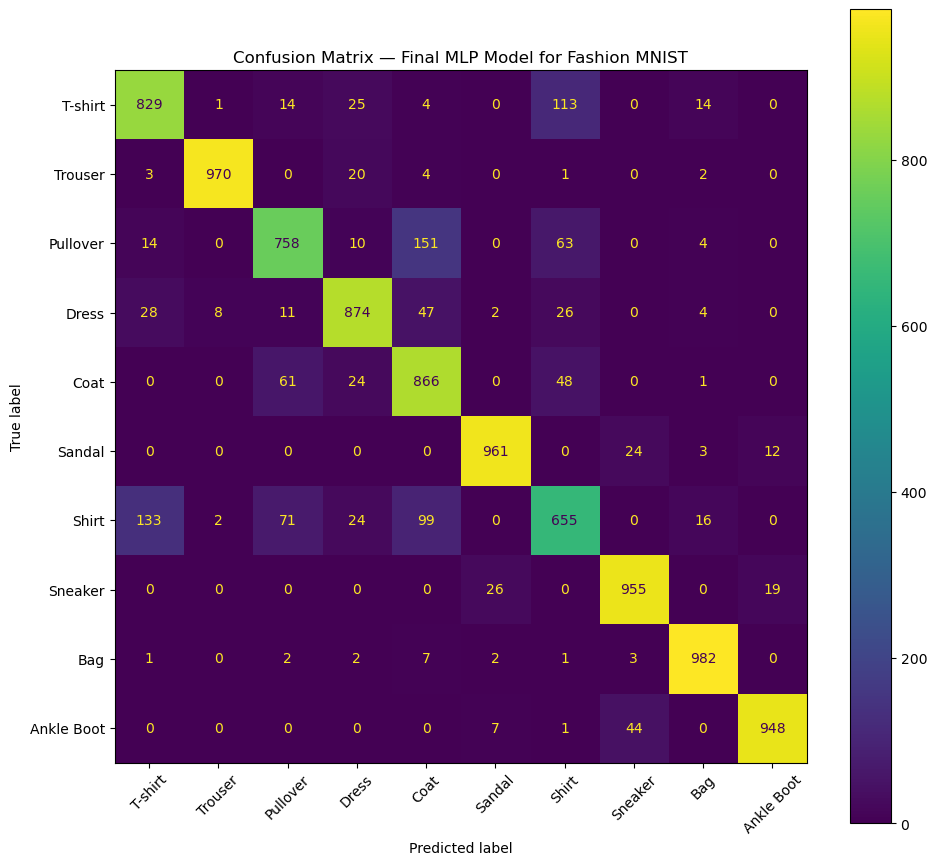

In [124]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

class_names = ['T-shirt', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle Boot']

cm = confusion_matrix(all_labels, all_predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

fig, ax = plt.subplots(figsize=(10, 9))
disp.plot(ax=ax, xticks_rotation=45)
plt.title('Confusion Matrix — Final MLP Model for Fashion MNIST')
plt.tight_layout()
plt.show()

In [126]:
from sklearn.metrics import classification_report

class_names = ['T-shirt', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle Boot']

report = classification_report(
    all_labels, 
    all_predictions, 
    target_names=class_names
)

print(report)

              precision    recall  f1-score   support

     T-shirt       0.82      0.83      0.83      1000
     Trouser       0.99      0.97      0.98      1000
    Pullover       0.83      0.76      0.79      1000
       Dress       0.89      0.87      0.88      1000
        Coat       0.74      0.87      0.80      1000
      Sandal       0.96      0.96      0.96      1000
       Shirt       0.72      0.66      0.69      1000
     Sneaker       0.93      0.95      0.94      1000
         Bag       0.96      0.98      0.97      1000
  Ankle Boot       0.97      0.95      0.96      1000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



### Reflection

Some bugs that I encountered during the project includes inconsistency between runs because random seeds were not being reset. When running some of the final models, performance was decreasing despite rerunning code. I realized it's optimal to rerun random seeds, model, and optimizer. Using an old optimizer with a new model causes incorrect weight adjustments since the optimizer is based off of the old parameters. Also, normalization was initially applied during FashionMNIST importing, but following the professor's loading code for test set without normalization, I find that performance significantly improved. The normalization had negative pixel values and somehow caused neurons to output zero.

Key takeaway is that experimentation needs to have isolated configurations. Combining everything that seemed favorable in the final model initially yielded worse results. In the end, a simpler model with only dropout, slower learning rate, and more hidden layers worked the best. It's best to change one thing at a time to understand what can imrpove model performance. 

Besides configurations that worked well, the ones that didn't included faster learning rate (unstable and overshooting), more epochs(overfitting), Tanh (unstable validation loss), and combining too many things together simultaneously. Data augmentation did seem to improve performance but was immensely slower compared to other techniques, making it impractical for this project.